In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Load the dataset
Netflex = pd.read_csv('netflix_titles.csv')

In [52]:
Netflex.head(50)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,David Attenborough,[United States],2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[South Africa],2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[United States],2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[United States],2021-09-24,2021,TV-MA,1 Season,International TV Shows,To protect his family from a powerful drug lor...
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[United States],2021-09-24,2021,TV-MA,1 Season,TV Action & Adventure,To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Rajiv Chilaka,David Attenborough,[United States],2021-09-24,2021,TV-MA,1 Season,Docuseries,"Feuds, flirtations and toilet talk go down amo..."
3,s4,TV Show,Jailbirds New Orleans,Rajiv Chilaka,David Attenborough,[United States],2021-09-24,2021,TV-MA,1 Season,Reality TV,"Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Rajiv Chilaka,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",[India],2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,In a city of coaching centers known to train I...


In [3]:
Netflex.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
Netflex.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [5]:
Netflex.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
Netflex.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
Netflex['director'] = Netflex['director'].fillna(Netflex['director'].mode()[0])
Netflex['cast'] = Netflex['cast'].fillna(Netflex['cast'].mode()[0])
Netflex['country'] = Netflex['country'].fillna(Netflex['country'].mode()[0])
Netflex['date_added'] = Netflex['date_added'].fillna(Netflex['date_added'].mode()[0])
Netflex['rating'] = Netflex['rating'].fillna(Netflex['rating'].mode()[0])
Netflex['duration'] = Netflex['duration'].fillna(Netflex['duration'].mode()[0])

In [8]:
Netflex.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

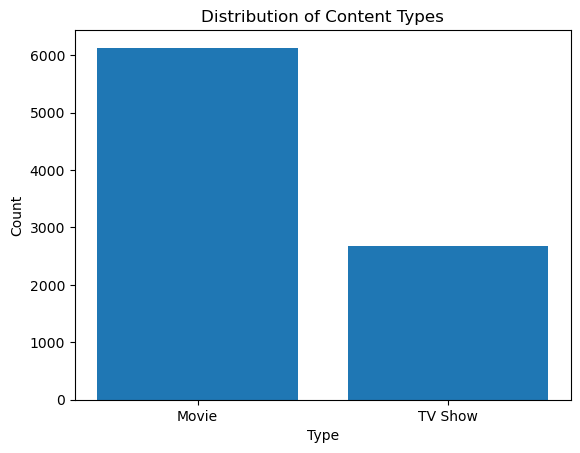

In [9]:
plt.bar(Netflex['type'].value_counts().index, Netflex['type'].value_counts().values)
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Distribution of Content Types')
plt.show()

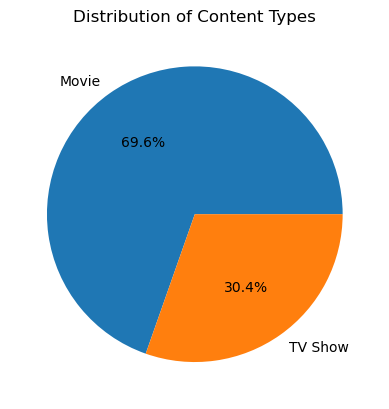

In [10]:
plt.pie(Netflex['type'].value_counts().values, labels=Netflex['type'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribution of Content Types')
plt.show()

Questions:
Which years had the most releases?
Did Netflix rapidly expand after a certain year?
Skills:
Datetime conversion
Line plots

In [13]:
Netflex['date_added'] = Netflex['date_added'].str.strip()
Netflex['date_added'] = pd.to_datetime(Netflex['date_added'])

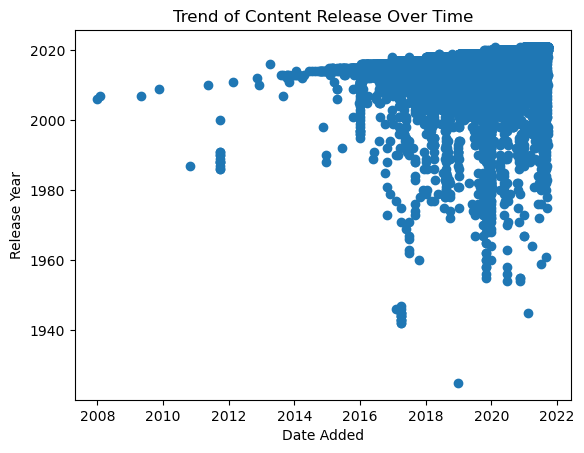

In [14]:
plt.plot(Netflex['date_added'], Netflex['release_year'], 'o')
plt.xlabel('Date Added')
plt.ylabel('Release Year')
plt.title('Trend of Content Release Over Time')
plt.show()

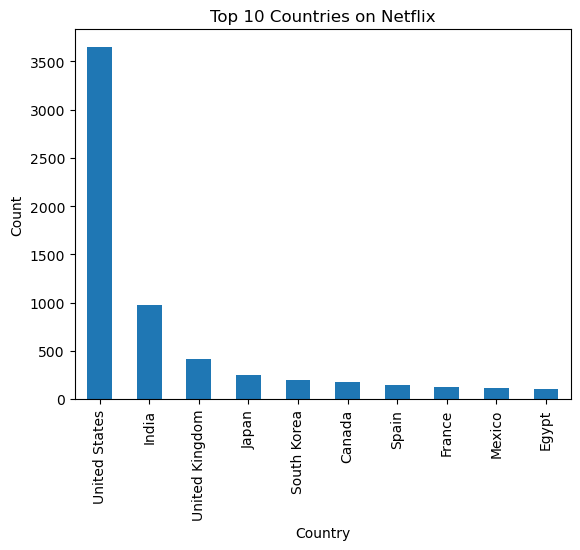

In [17]:
Netflex['country'].value_counts().head(10).plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 10 Countries on Netflix')

plt.show()

In [22]:
Netflex['rating'].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [23]:
Netflex['rating'].value_counts().head(1)

rating
TV-MA    3211
Name: count, dtype: int64

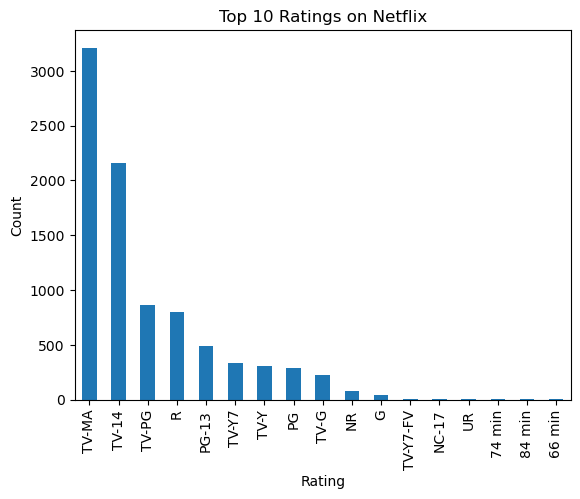

In [ ]:
Netflex['rating'].value_counts().plot(kind='bar')

plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Content Ratings')

plt.show()

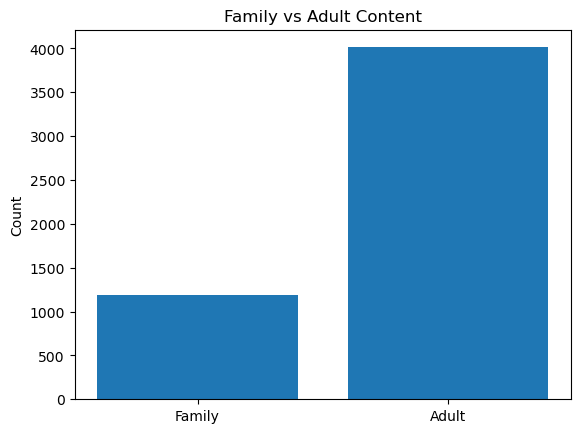

In [26]:
family = ['TV-Y', 'TV-Y7', 'G', 'PG', 'TV-G']
adult = ['TV-MA', 'R', 'NC-17']

family_count = Netflex['rating'].isin(family).sum()
adult_count = Netflex['rating'].isin(adult).sum()

categories = ['Family', 'Adult']
counts = [family_count, adult_count]

plt.bar(categories, counts)

plt.title('Family vs Adult Content')

plt.ylabel('Count')

plt.show()

In [37]:
Netflex['country'] = Netflex['country'].str.split(', ')

In [38]:
Netflex['country'].head()

0    [United States]
1     [South Africa]
2    [United States]
3    [United States]
4            [India]
Name: country, dtype: object

In [35]:
Netflex['listed_in'] = Netflex['listed_in'].str.split(', ')

In [36]:
Netflex['listed_in'].head()

0                                      [Documentaries]
1    [International TV Shows, TV Dramas, TV Mysteries]
2    [Crime TV Shows, International TV Shows, TV Ac...
3                             [Docuseries, Reality TV]
4    [International TV Shows, Romantic TV Shows, TV...
Name: listed_in, dtype: object

In [39]:
Netflex = Netflex.explode('listed_in')

In [42]:
genre_counts = Netflex['listed_in'].value_counts()

print(genre_counts.head(10))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


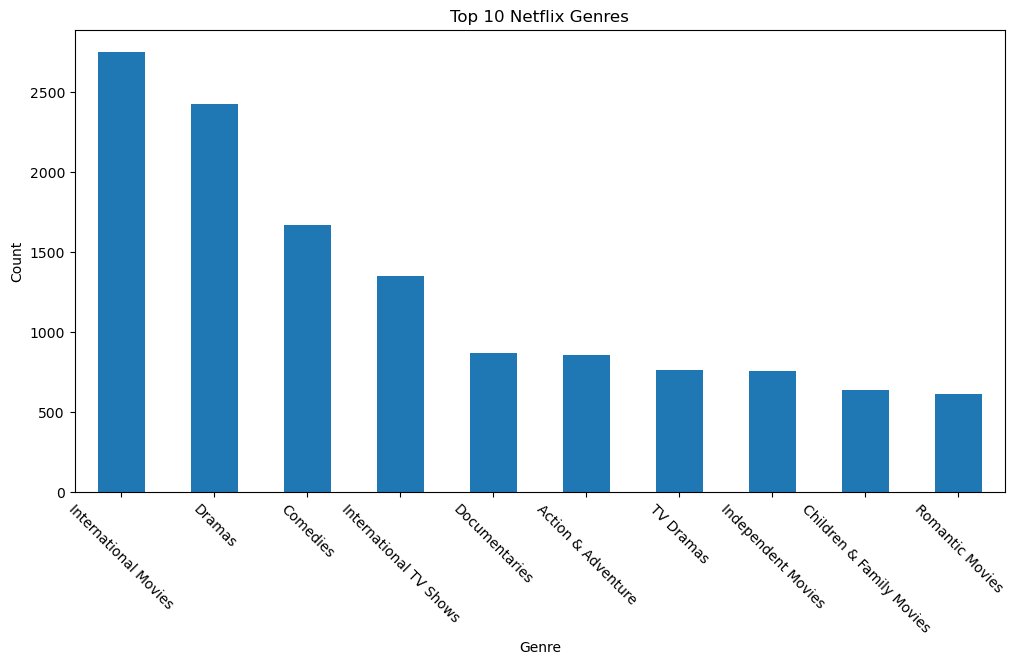

In [45]:
top_genres = Netflex['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_genres.plot(kind='bar')

plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.xticks(rotation=-45)

plt.show()

In [46]:
Netflex.info()

<class 'pandas.DataFrame'>
Index: 19323 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       19323 non-null  str           
 1   type          19323 non-null  str           
 2   title         19323 non-null  str           
 3   director      19323 non-null  str           
 4   cast          19323 non-null  str           
 5   country       19323 non-null  object        
 6   date_added    19323 non-null  datetime64[us]
 7   release_year  19323 non-null  int64         
 8   rating        19323 non-null  str           
 9   duration      19323 non-null  str           
 10  listed_in     19323 non-null  str           
 11  description   19323 non-null  str           
dtypes: datetime64[us](1), int64(1), object(1), str(9)
memory usage: 1.9+ MB
